In [1]:
from pathlib import Path

import numpy as onp
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
BASERESULTSDIR = Path("example_results/")

plt.rcParams["font.size"] = 12
markerlist = ["o", "s", "d", "v", "^"]
# Settings for annotating the data points with the cutoff
# See https://matplotlib.org/stable/users/explain/artists/
ha = "center"
va = "top"
dx, dy = -3 / 72.0, -4 / 72.0

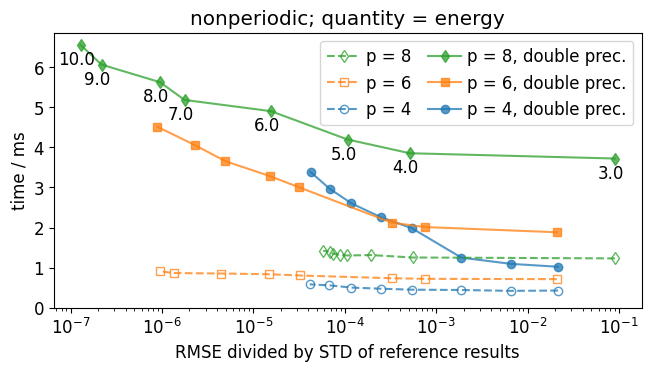

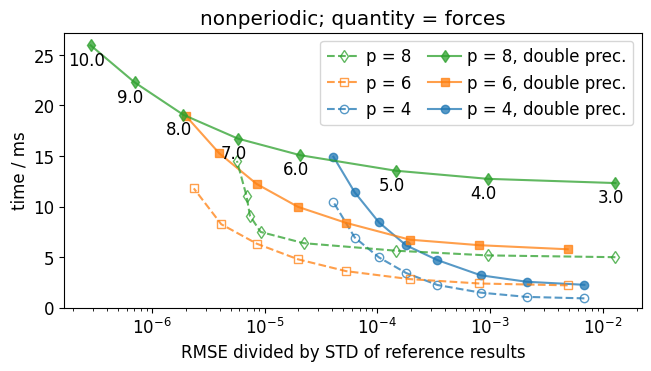

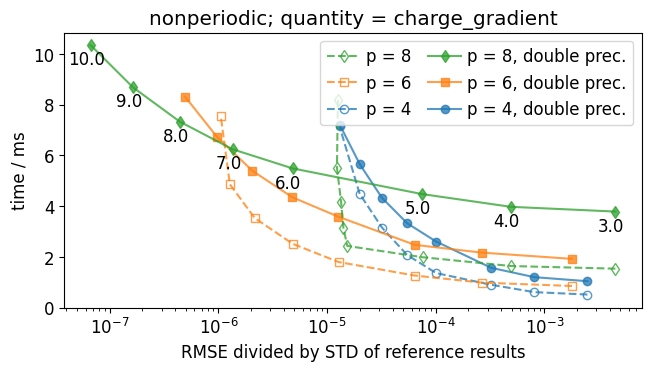

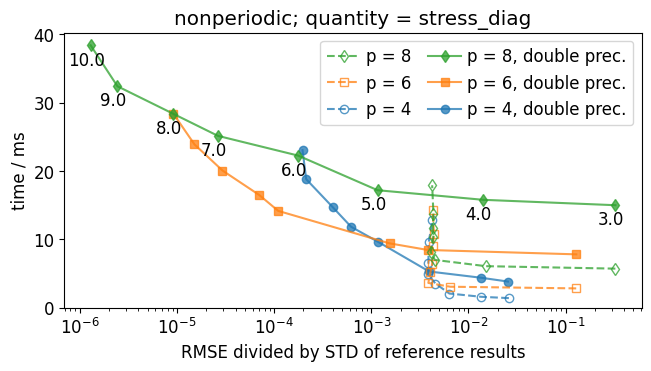

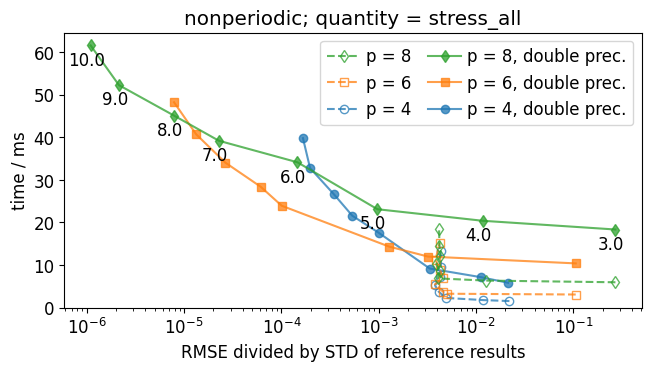

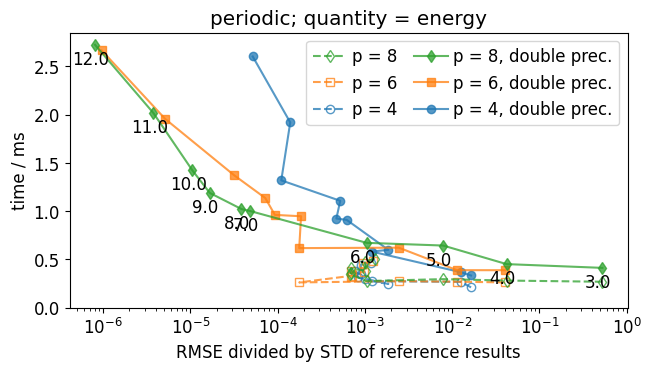

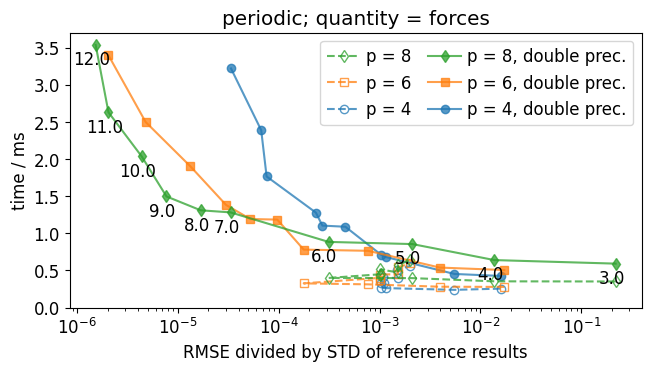

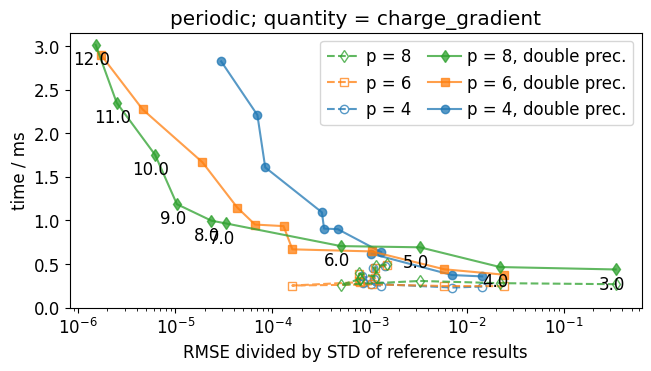

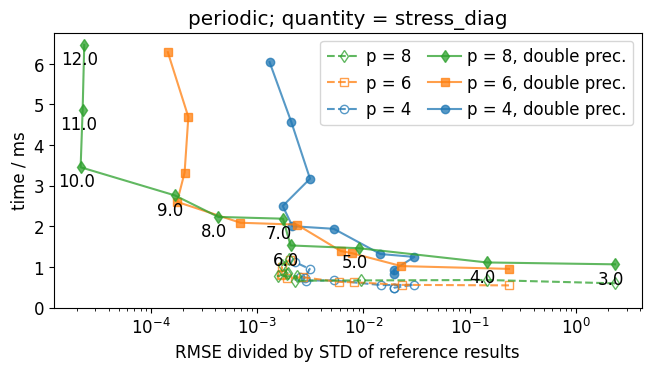

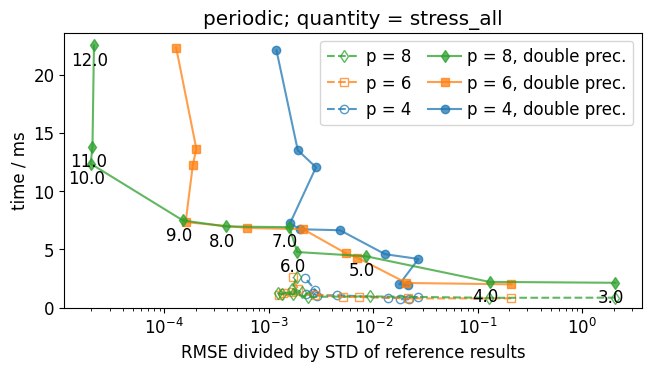

In [3]:
for pbclabel in ["nonperiodic", "periodic"]:
    results = []
    resultsdirname = pbclabel
    df = pd.read_csv(BASERESULTSDIR / resultsdirname / "results.csv")
    df.insert(len(df.columns), "double_precision", [False] * len(df))
    results.append(df)
    resultsdirname += "_doubleprec"
    df = pd.read_csv(BASERESULTSDIR / resultsdirname / "results.csv")
    df.insert(len(df.columns), "double_precision", [True] * len(df))
    results.append(df)
    results = pd.concat(results)

    for quantity in [
        "energy",
        "forces",
        "charge_gradient",
        "stress_diag",
        "stress_all",
    ]:
        unique_ps = results.loc[results["quantity"] == quantity, "p"].unique()
        unique_ps = onp.sort(unique_ps)
        fig, ax = plt.subplots(figsize=(6.4, 3.6), layout="constrained")
        ax.set_title(f"{pbclabel}; quantity = {quantity}")
        ax.set_xlabel("RMSE divided by STD of reference results")
        ax.set_ylabel("time / ms")
        ax.set_xscale("log")
        offset = mpl.transforms.ScaledTranslation(dx, dy, fig.dpi_scale_trans)
        annotations_transform = ax.transData + offset
        lines = []
        for p, marker in zip(unique_ps, markerlist):
            for doubleprec, linestyle, markerfacecolor in zip(
                [False, True], ["--", "-"], ["none", None]
            ):
                selection = results.loc[
                    (
                        (results["p"] == p)
                        & (results["quantity"] == quantity)
                        & (results["double_precision"] == doubleprec)
                    )
                ]
                cutoffs = selection["level_zero_cutoff"].values
                errors = selection["relative_rmse"].values
                times = selection["time"].values * 10**3
                if doubleprec:
                    color = lines[-1].get_color()
                else:
                    color = None
                label = f"p = {p}"
                if doubleprec:
                    label += ", double prec."
                lines += ax.plot(
                    errors,
                    times,
                    alpha=0.75,
                    marker=marker,
                    markerfacecolor=markerfacecolor,
                    linestyle=linestyle,
                    color=color,
                    label=label,
                )

        # Annotate only the last graph
        for r_cut, err, t in zip(cutoffs, errors, times):
            xy = (err, t)
            ax.annotate(
                f"{r_cut:.1f}",
                xy,
                xytext=xy,
                textcoords=annotations_transform,
                ha=ha,
                va=va,
            )

        ax.set_ylim(bottom=0.0)
        reordered_lines = lines[1::2] + lines[::2]
        ax.legend(
            ncols=2,
            columnspacing=1.0,
            handletextpad=0.35,
            handles=reordered_lines,
            reverse=True,
        )

        filename_without_suffix = (
            "cost_vs_accuracy" + "_" + pbclabel + "_" + quantity
        )
        for suffix in [".png", ".pdf"]:
            fig.savefig(BASERESULTSDIR / (filename_without_suffix + suffix))

        plt.show()